# 04 — Perceptron

The weakest linear baseline in the lineup. Included as a
sanity-check floor against which the more sophisticated
models are measured. Approaches its Bayes-error rate, then
plateaus.

## 1 — Setup

Configure matplotlib for inline rendering, add the project
root to `sys.path` so we can import from `src/`, and pull in
the shared helpers + the project-wide `RANDOM_STATE = 42`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# `notebooks/` is one level below the project root; add the
# project root so `from src import ...` resolves correctly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (single source of truth in src.train_utils)")

RANDOM_STATE = 42 (single source of truth in src.train_utils)


## 2 — Load the preprocessed feature matrices

`load_preprocessed()` returns the two parallel matrices
produced by Phase 1: the **Baseline** (nutrition + tags only)
and the **Advanced** (Baseline + 9 engineered culinary
features). Both share the same train/test partition so the
A/B comparison is apples-to-apples.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 — Configure the model

Default Perceptron with `random_state=RANDOM_STATE` for
the SGD shuffling RNG; `max_iter=1000` and `tol=1e-3`
match the sklearn defaults.

In [3]:
from sklearn.linear_model import Perceptron

MODEL_SLUG    = "perceptron"
MODEL_NAME    = "Perceptron"
DISPLAY_NAME  = "Perceptron"

MODEL_CONFIG = {
    "max_iter":     1000,
    "tol":          1e-3,
    "random_state": RANDOM_STATE,
}
MODEL_CONFIG

{'max_iter': 1000, 'tol': 0.001, 'random_state': 42}

## 4 — Train on both matrices

Each matrix gets a **fresh** model instance (the factory
below is called once per dataset). Nothing carries over
between Baseline and Advanced — that's how the engineered
feature delta stays attributable to the additional 9 columns
alone.

In [4]:
def _build_model():
    return Perceptron(**MODEL_CONFIG)

per_ds_results = {}
for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    print_dataset_block(ds_name, X_train.shape, result)
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5495
     Test F1-Score : 0.5726
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          903       795   FP rate = 0.4682
        True:Hit           847      1100   FN rate = 0.4350

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5457
     Test F1-Score : 0.5696
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          893       805   FP rate = 0.4741
        True:Hit           851      1096   FN rate = 0.4371

  >> Δ (Advanced − Baseline):  Acc -0.0038  |  F1 -0.0030


## 5 — Confusion matrix (Advanced fit)

Annotated heatmap of the Advanced-fit confusion matrix.
Rendered inline AND persisted to
`results/<slug>/confusion_matrix.png`.

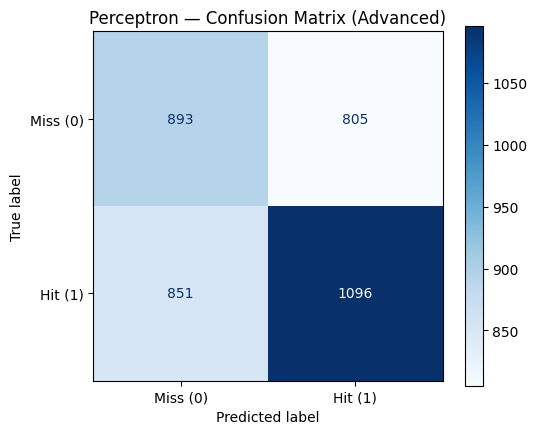

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} — Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 — ROC curve + AUC (Advanced fit)

Generated against `predict_proba` (or `decision_function`
where probabilities aren't available). The AUC is the
ranking-quality summary independent of any threshold choice;
Phase 4's threshold-sweep work depends on it.

Test ROC AUC (Advanced): 0.5644


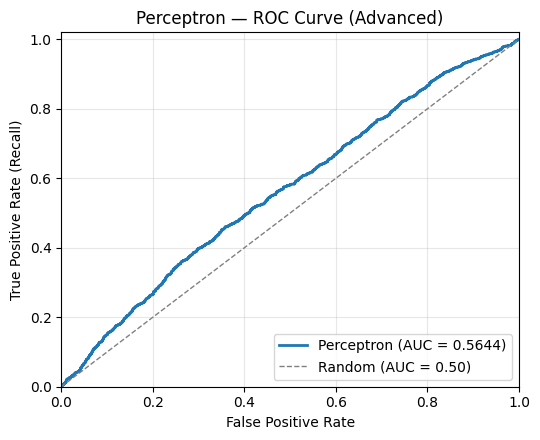

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} — ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 — Persist the canonical metrics JSON

One JSON per model, written to
`results/<slug>/metrics.json`. Schema is defined in
`src.train_utils.build_metrics_payload`; the master
comparison notebook reads from here.

In [7]:
extras = {}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/perceptron/metrics.json


## 9 — Summary

    **Model:** Perceptron

    - **Test Accuracy / F1:** ~0.5457 / ~0.5696 — the weakest
  model in the lineup.
- **Nearly symmetric errors** (FP ≈ FN), in contrast to
  AdaBoost's strong asymmetry.

    Run the **master comparison notebook
    (`08_Master_Comparison.ipynb`)** to see this model alongside
    the other six in the side-by-side table.